# **EXOPLANET HABITABILITY CLASSIFICATION PROJECT**

### RIDIMA

This notebook is a ML project, classifying exoplanets on their habitability from various mission data. 

In [1]:
#Import all the essentials libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler


#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn import tree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [2]:
#Open the data
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007,2014-05-14,...,0,Hot,0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.86330,1.29
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009,2018-09-06,...,0,Hot,0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.78480,1.53
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008,2014-05-14,...,0,Hot,0,0.081917,Andromeda,And,Andromeda,12.848516,1525.57440,0.83
3,14 Her b,3.0,1481.07850,-47.67420,47.67420,NaN,NaN,NaN,2002,2018-09-06,...,0,Cold,0,0.145241,Hercules,Her,Hercules,12.865261,1481.07850,2.93
4,16 Cyg B b,3.0,565.73385,-25.42624,25.42624,NaN,NaN,NaN,1996,2018-09-06,...,1,Warm,0,0.368627,Cygnus,Cyg,Swan,13.421749,565.73385,1.66


In [3]:
with open("column_names.txt", "w") as f:
    for i, col in enumerate(df.columns, start=1):
        f.write(f"{i}. {col}\n")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Columns: 112 entries, P_NAME to P_SEMI_MAJOR_AXIS_EST
dtypes: float64(94), int64(4), object(14)
memory usage: 3.5+ MB


In [5]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

Rows: 4048
Columns: 112


In [6]:
null_vales = df.isnull().sum().sort_values(ascending = False)
null_vales.head(40)

P_ATMOSPHERE                    4048
P_ALT_NAMES                     4048
P_DETECTION_RADIUS              4048
P_GEO_ALBEDO                    4048
P_DETECTION_MASS                4048
S_MAGNETIC_FIELD                4048
S_DISC                          4048
P_TEMP_MEASURED                 4043
P_GEO_ALBEDO_ERROR_MIN          4043
P_GEO_ALBEDO_ERROR_MAX          4043
P_TPERI_ERROR_MAX               3576
P_TPERI_ERROR_MIN               3576
P_TPERI                         3567
P_OMEGA_ERROR_MIN               3355
P_OMEGA_ERROR_MAX               3355
P_ESCAPE                        3342
P_POTENTIAL                     3342
P_DENSITY                       3342
P_GRAVITY                       3342
P_OMEGA                         3302
P_INCLINATION_ERROR_MAX         3238
P_INCLINATION_ERROR_MIN         3236
P_INCLINATION                   3204
P_ECCENTRICITY_ERROR_MIN        3077
P_ECCENTRICITY_ERROR_MAX        3077
S_TYPE                          2678
P_ECCENTRICITY                  2668
P

### **PREPRCESSING**

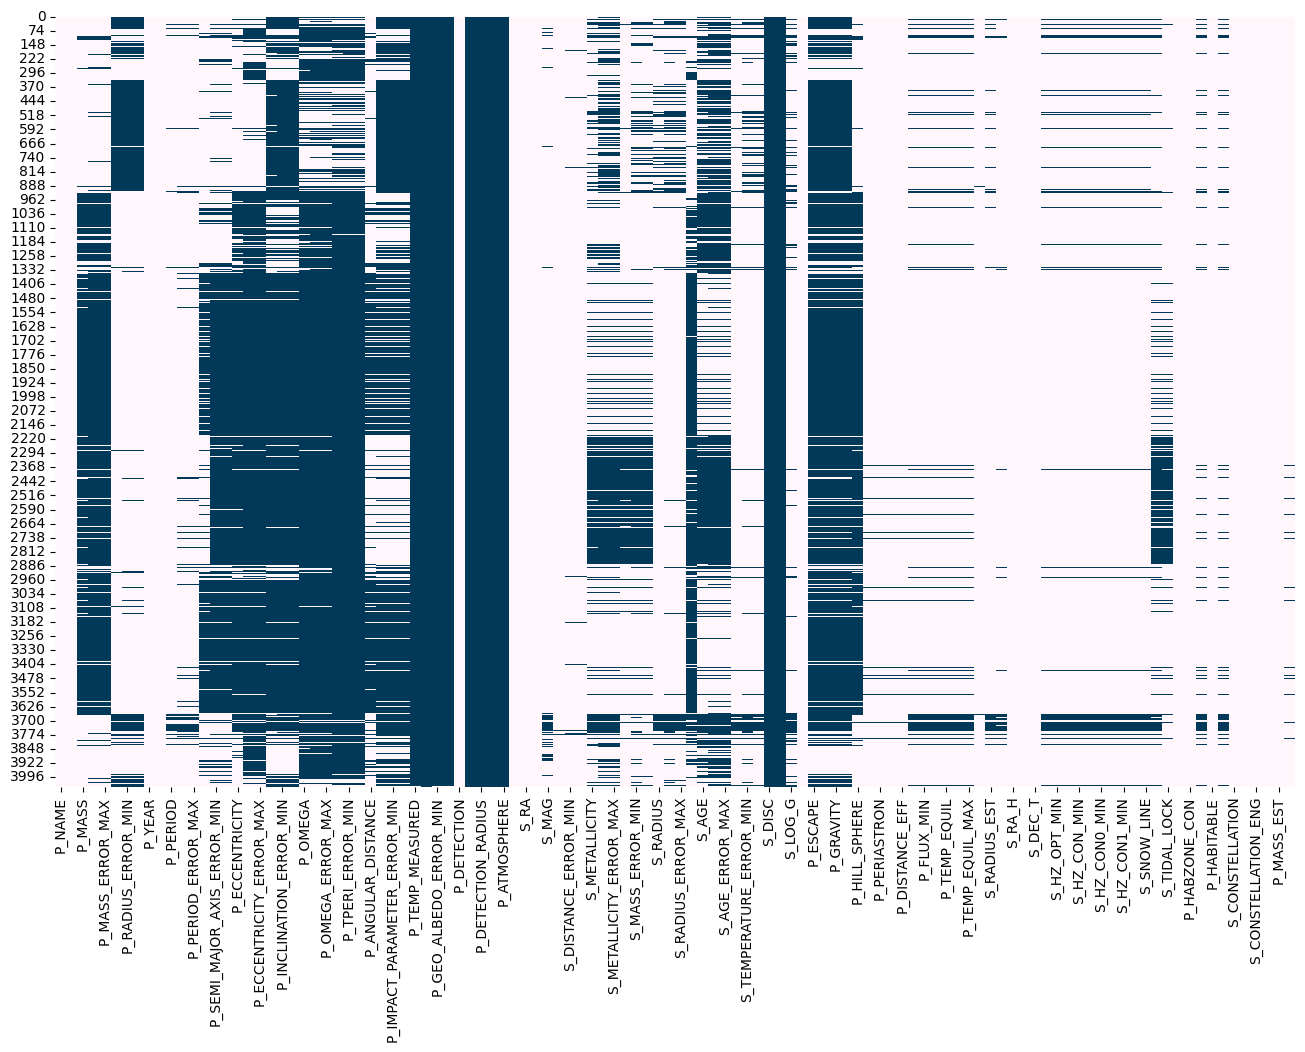

In [7]:
#Plots a heatmap of the missing values in the dataset
plt.figure(figsize=(16, 10))

sns.heatmap(df.isnull(), cbar=False, cmap='PuBu') 
plt.show()

In [8]:
df.isnull().sum().sort_values(ascending=False)

P_ATMOSPHERE           4048
P_ALT_NAMES            4048
P_DETECTION_RADIUS     4048
P_GEO_ALBEDO           4048
P_DETECTION_MASS       4048
                       ... 
P_HABITABLE               0
S_CONSTELLATION_ABR       0
S_CONSTELLATION_ENG       0
P_RADIUS_EST              0
P_MASS_EST                0
Length: 112, dtype: int64

In [9]:
#Dropping all the columns with null  values
df = df.drop(["P_DETECTION_MASS", "P_GEO_ALBEDO", "S_MAGNETIC_FIELD", "S_DISC", "P_ATMOSPHERE", "P_ALT_NAMES", "P_DETECTION_RADIUS", "P_GEO_ALBEDO_ERROR_MIN", "P_TEMP_MEASURED", "P_GEO_ALBEDO_ERROR_MAX","P_TPERI_ERROR_MAX", "P_TPERI_ERROR_MIN", "P_TPERI", "P_OMEGA_ERROR_MIN", "P_OMEGA_ERROR_MAX", "P_OMEGA",   "P_INCLINATION_ERROR_MAX", "P_INCLINATION_ERROR_MIN", "P_INCLINATION", "P_ECCENTRICITY_ERROR_MAX", "P_ECCENTRICITY_ERROR_MIN", "P_IMPACT_PARAMETER_ERROR_MIN", "P_IMPACT_PARAMETER_ERROR_MAX", "P_IMPACT_PARAMETER", "P_MASS_ERROR_MAX", "P_MASS_ERROR_MIN", "P_HILL_SPHERE", "P_SEMI_MAJOR_AXIS_ERROR_MIN", "P_SEMI_MAJOR_AXIS_ERROR_MAX"], axis=1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Data columns (total 83 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   P_NAME                   4048 non-null   object 
 1   P_STATUS                 4048 non-null   float64
 2   P_MASS                   1598 non-null   float64
 3   P_RADIUS                 3139 non-null   float64
 4   P_RADIUS_ERROR_MIN       3105 non-null   float64
 5   P_RADIUS_ERROR_MAX       3105 non-null   float64
 6   P_YEAR                   4048 non-null   int64  
 7   P_UPDATED                4048 non-null   object 
 8   P_PERIOD                 3938 non-null   float64
 9   P_PERIOD_ERROR_MIN       3807 non-null   float64
 10  P_PERIOD_ERROR_MAX       3807 non-null   float64
 11  P_SEMI_MAJOR_AXIS        2367 non-null   float64
 12  P_ECCENTRICITY           1380 non-null   float64
 13  P_ANGULAR_DISTANCE       2361 non-null   float64
 14  P_DETECTION             

Our data is divided into categorical and numeric datatypes

In [11]:
#Null values in the categorical data columns
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

S_TYPE                 2678
P_TYPE_TEMP             327
S_TYPE_TEMP             136
P_TYPE                   17
P_UPDATED                 0
P_NAME                    0
S_ALT_NAMES               0
S_NAME                    0
P_DETECTION               0
S_RA_T                    0
S_DEC_T                   0
S_CONSTELLATION           0
S_CONSTELLATION_ABR       0
S_CONSTELLATION_ENG       0
dtype: int64

In [12]:
print(df['P_TYPE'])
df['P_TYPE'].isnull().sum()

0            Jovian
1            Jovian
2            Jovian
3            Jovian
4            Jovian
           ...     
4043    Superterran
4044      Neptunian
4045         Terran
4046         Terran
4047         Terran
Name: P_TYPE, Length: 4048, dtype: object


np.int64(17)

The “P_TYPE” column in our data describes the exoplanet category and consists of six possible values: Jovian, Superterran, Neptunian, Terran, Subterran, and Miniterran. This feature had 17 missing values.

TO handle the missing values, we can impute them using mode

In [13]:
df['P_TYPE'] = df['P_TYPE'].fillna(df['P_TYPE'].mode()[0]) #set the first most common value
df['P_TYPE_TEMP'] = df['P_TYPE_TEMP'].fillna(df['P_TYPE_TEMP'].mode()[0])
df['S_TYPE_TEMP'] = df['S_TYPE_TEMP'].fillna(df['S_TYPE_TEMP'].mode()[0]) 

In [14]:
#Converting sll the categorical data into integer data
lencoders = {}
for col in df.select_dtypes(include=['object']).columns:
    lencoders[col] = LabelEncoder()
    df[col] = lencoders[col].fit_transform(df[col])

nOw WE HANDLED MISSING VALUES IN CATEGORICAL DATA and encoded them, NO WE WILL WORK UPON NUMERICAL DATA 

We are going to use Scikit-learn's imputer because it provides a systematic way to replace missing numerical data, and IterativeImputer is particularly useful when we want to use relationships between multiple features to make those replacements.


In [15]:
imp = IterativeImputer(max_iter=10, verbose=0) #Creates an iterative imputer object
imp.fit(df) #Fits the imputer to the dataframe
imputed_df = imp.transform(df) #Transforms the data
df = pd.DataFrame(imputed_df, columns=df.columns) #Creates a dataframe from the imputed data. 

In [16]:
# Checking for missing values
df.isnull().sum().sort_values(ascending=False)


P_NAME                   0
P_STATUS                 0
P_MASS                   0
P_RADIUS                 0
P_RADIUS_ERROR_MIN       0
                        ..
S_CONSTELLATION_ABR      0
S_CONSTELLATION_ENG      0
P_RADIUS_EST             0
P_MASS_EST               0
P_SEMI_MAJOR_AXIS_EST    0
Length: 83, dtype: int64

we have corrected all of our missing values! But, we still have a major class imbalance to work with. Since we don’t know of many potentially habitable planets, the number of inhabitable exoplanets greatly outnumbers the habitable ones. This will likely cause our model to guess an exoplanet is inhabitable, even if it’s not the case, because it will still have an average of like 99% accuracy. Thus, we need to find a way to balance the scales.

We will use upsampling method, using algorithm SMOTE.

In [17]:
# Checking if imbalance is fixed
df['P_HABITABLE'].value_counts()

P_HABITABLE
0.0    3993
2.0      34
1.0      21
Name: count, dtype: int64

In [18]:
df.shape

(4048, 83)

<Axes: >

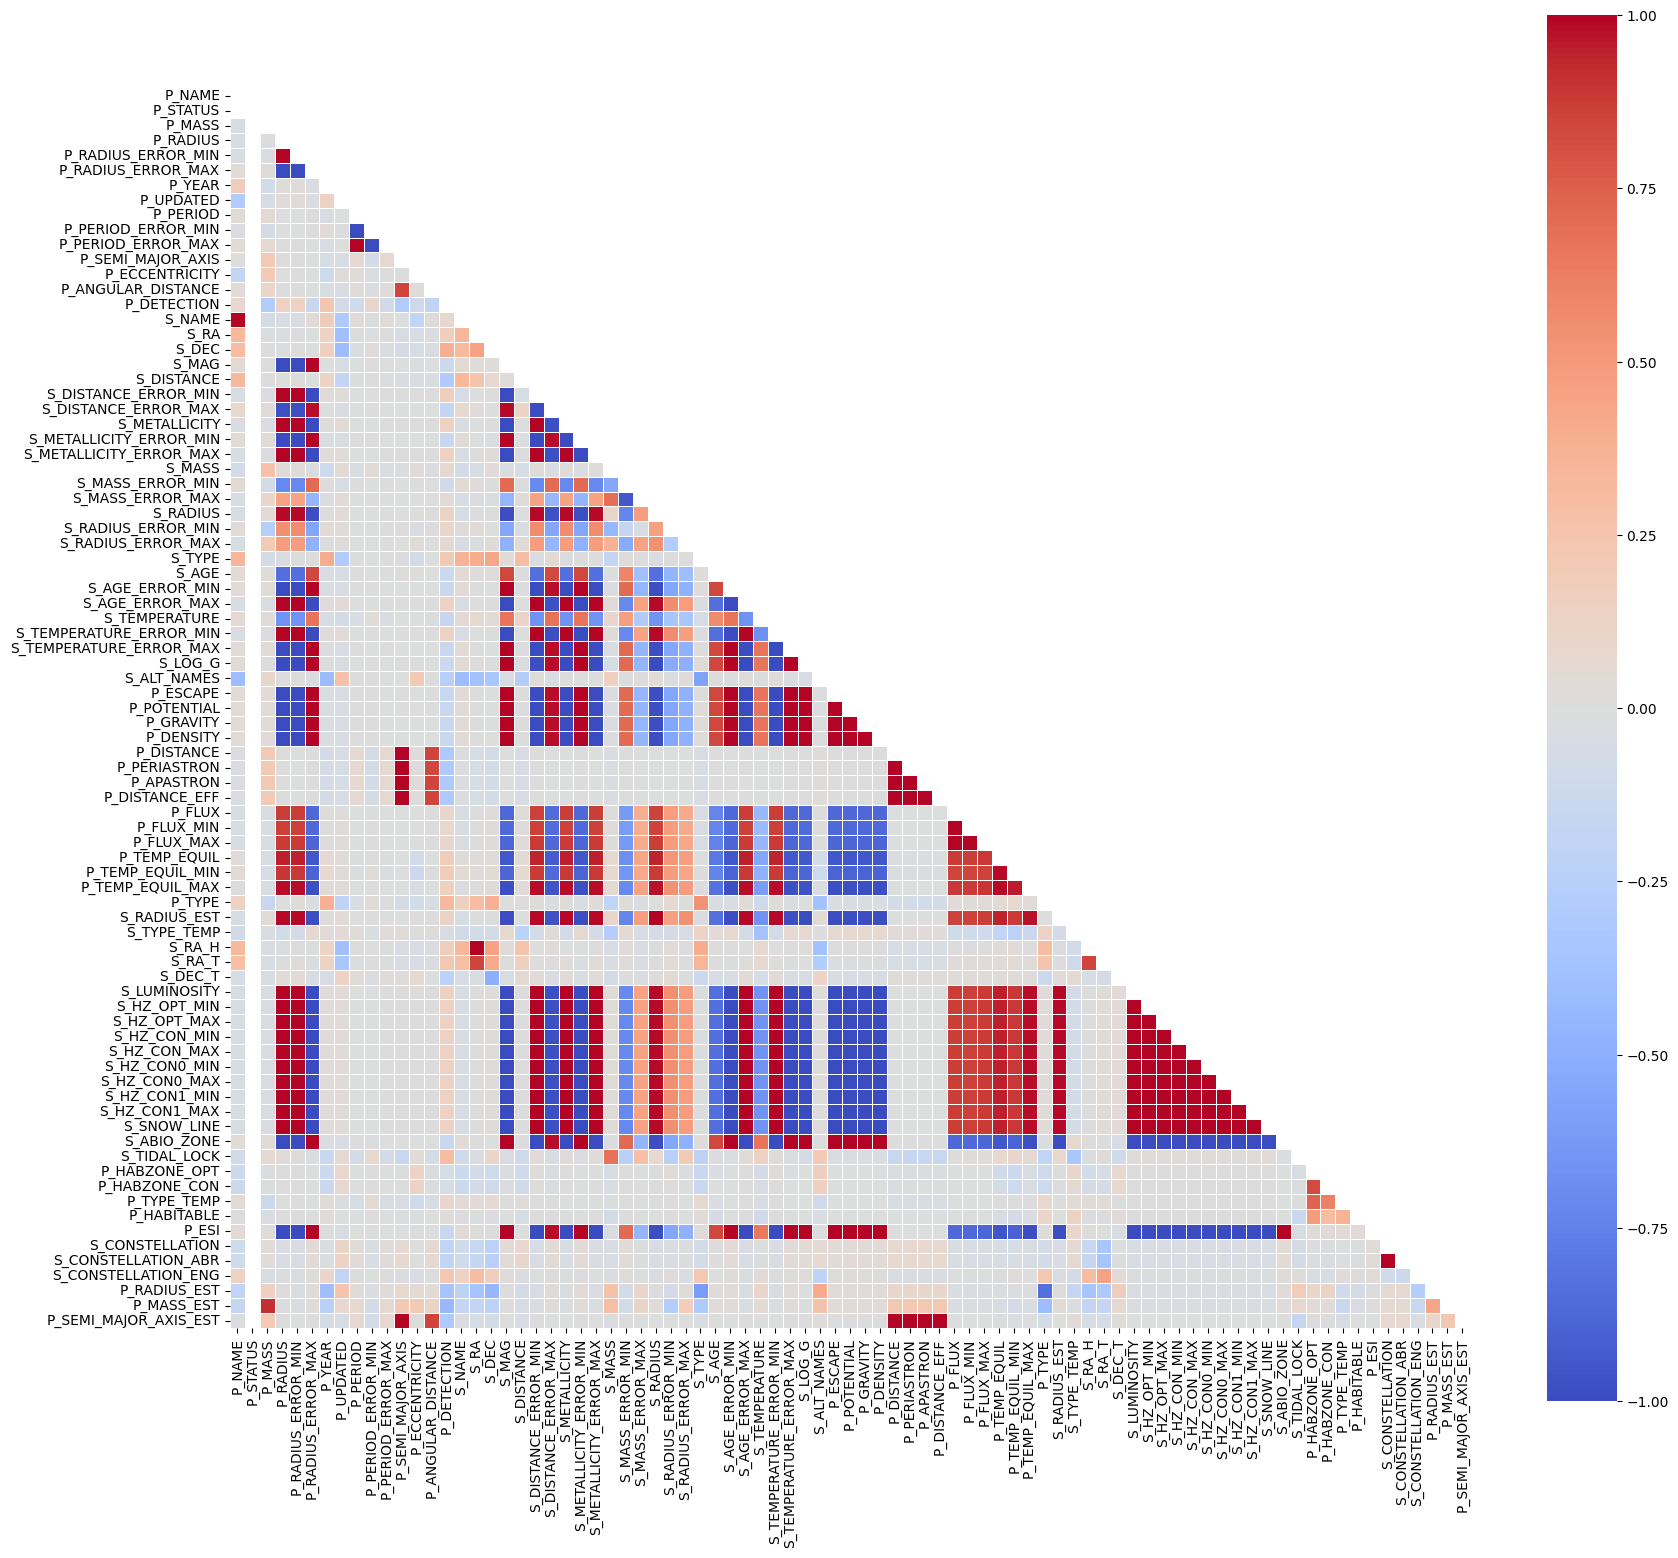

In [19]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

In [20]:
#Dropping one of each which are highly corelated to each other
working_data = df.drop(['P_DISTANCE_EFF','P_APASTRON','P_PERIASTRON','S_HZ_OPT_MAX','S_HZ_CON_MIN','S_HZ_CON_MAX','S_HZ_CON0_MIN','S_HZ_CON0_MAX','S_HZ_CON1_MIN','S_HZ_CON1_MAX','S_SNOW_LINE','P_HABZONE_OPT', 'P_HABZONE_CON', 'P_ESI', 'S_RA_H','S_AGE_ERROR_MIN','S_AGE_ERROR_MAX','S_HZ_OPT_MIN','P_RADIUS_ERROR_MIN','P_RADIUS_ERROR_MAX','S_METALLICITY_ERROR_MIN','S_METALLICITY_ERROR_MAX','S_TEMPERATURE_ERROR_MIN','S_TEMPERATURE_ERROR_MAX','P_FLUX_MIN','P_FLUX_MAX','P_GRAVITY','P_DENSITY','P_POTENTIAL','P_ESCAPE','P_DISTANCE','P_SEMI_MAJOR_AXIS_EST','S_RADIUS_EST','S_CONSTELLATION_ABR','P_PERIOD_ERROR_MIN','P_PERIOD_ERROR_MAX',], axis=1)

Now we will visualize it using a correlation heatmap as the model might learn correlations that aren’t really related to the actual habitability of the planet.

The dark red squares indicate that the two corresponding variables are highly related to one another and might cause unwanted connections in our machine learning model.

<Axes: >

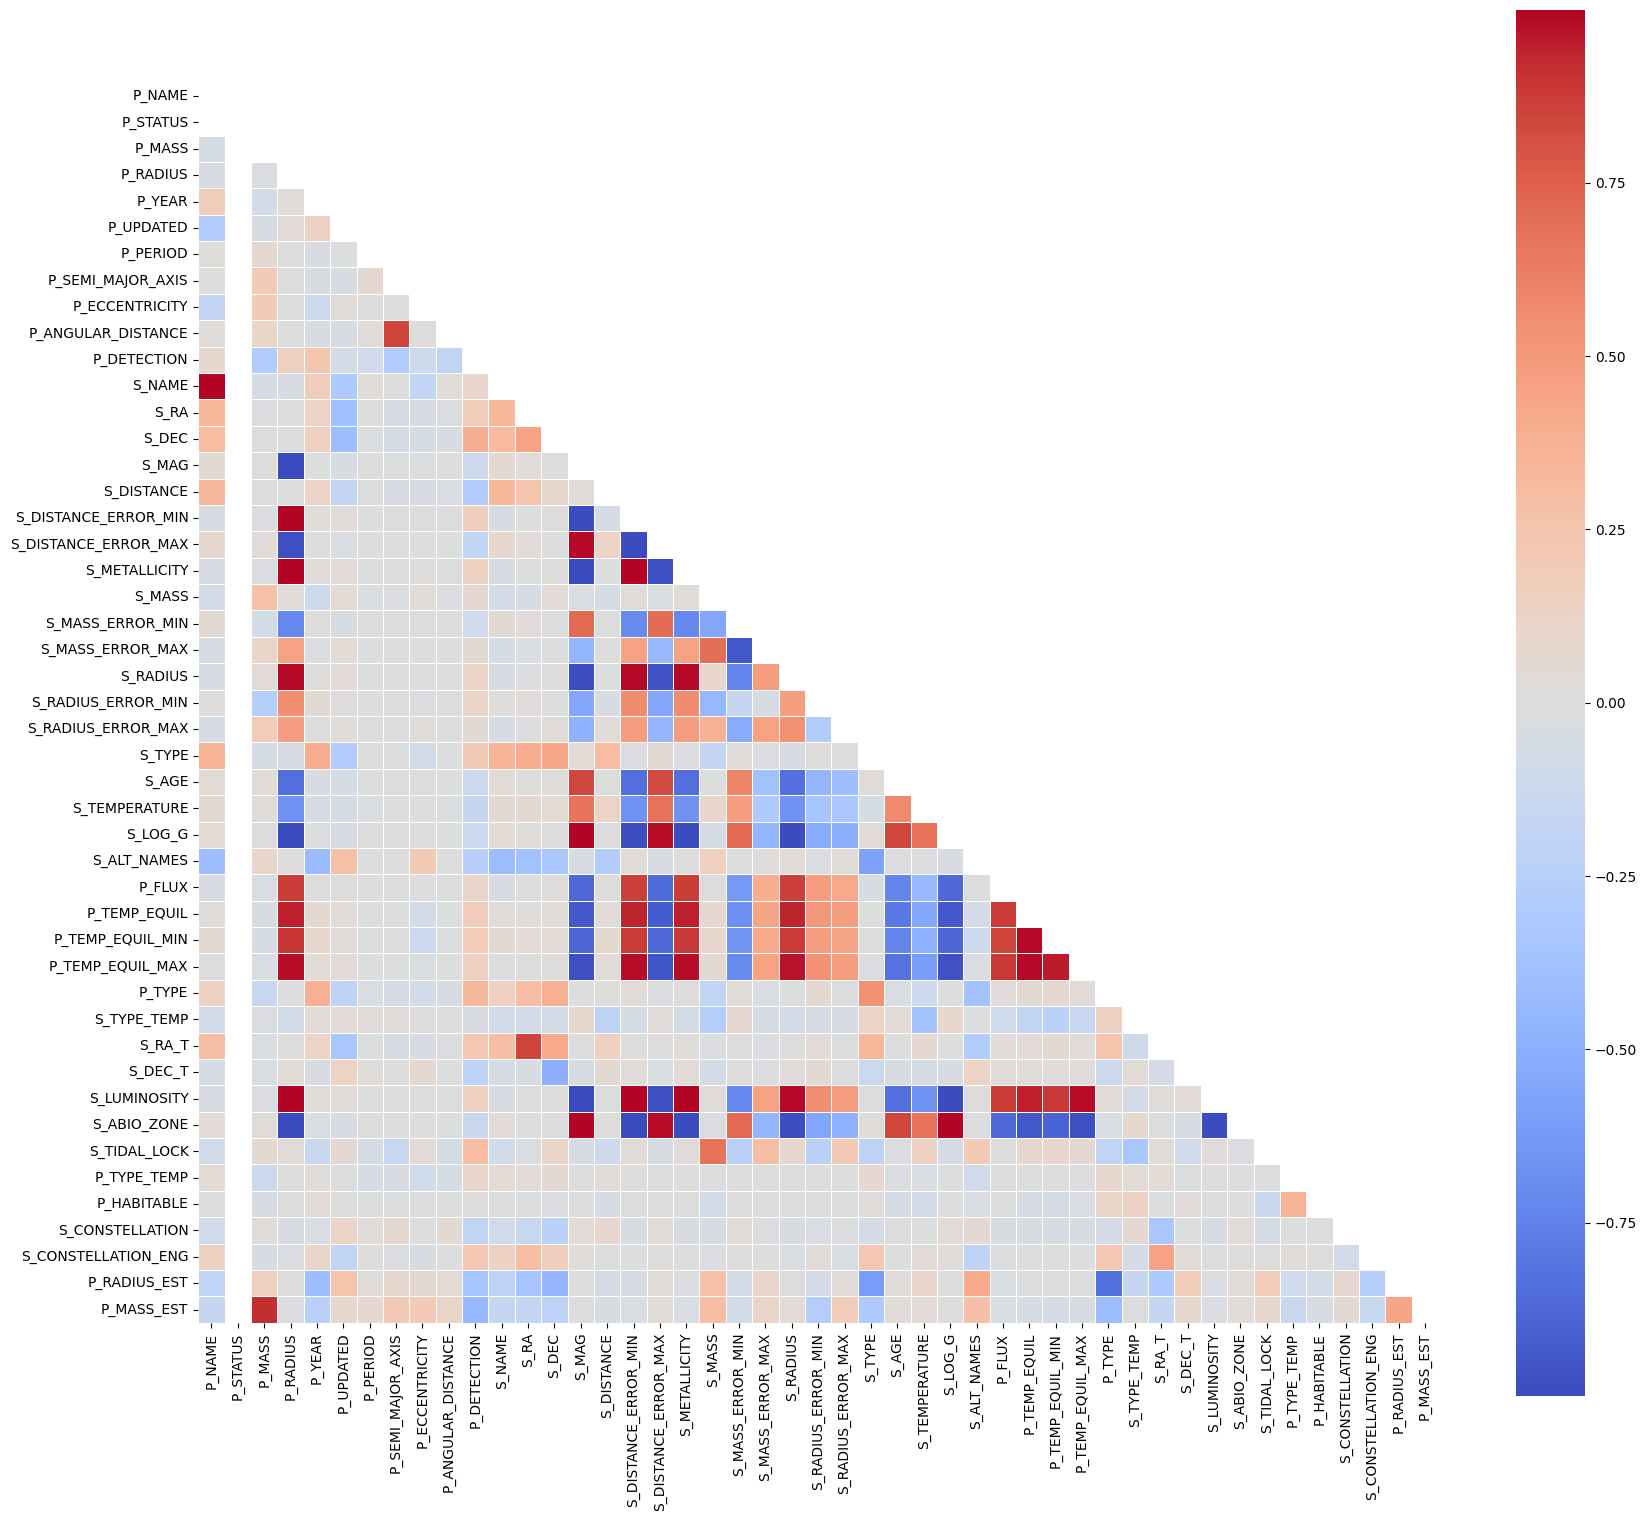

In [21]:
corr = working_data.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

In [56]:
working_data["P_STATUS"].value_counts()

P_STATUS
3.0    4048
Name: count, dtype: int64

In [22]:
#Since ther's only one value we can drop it 
working_data = working_data.drop('P_STATUS', axis = 1)

## **Splitting into Train/Test**

In [ ]:
X = working_data.drop('P_HABITABLE', axis = 1)
y = working_data["P_HABITABLE"]

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.25, random_state=42)
print("Training/testing: ", len(X_train), '/', len(X_test))


Training/testing:  3036 / 1012


In [24]:
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

df = pd.concat([pd.DataFrame(X_train_smote), pd.DataFrame(y_train_smote)], axis = 1 )
df.head()

,P_NAME,P_MASS,P_RADIUS,P_YEAR,P_UPDATED,P_PERIOD,P_SEMI_MAJOR_AXIS,P_ECCENTRICITY,P_ANGULAR_DISTANCE,P_DETECTION,...,S_DEC_T,S_LUMINOSITY,S_ABIO_ZONE,S_TIDAL_LOCK,P_TYPE_TEMP,S_CONSTELLATION,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_HABITABLE
0,2576.0,797.869256,2.667980,2014.0,0.0,11.979010,0.0970,0.161573,0.0892,8.0,...,1015.0,0.486654,1.768991e+35,0.440103,1.0,30.0,75.0,2.667980,7.597271,0.0
1,2910.0,92.170121,13.788300,2014.0,13.0,10.290994,0.0910,0.570000,0.0827,8.0,...,1190.0,1.847856,2.078366e+00,0.488088,1.0,51.0,49.0,13.788300,92.170121,0.0
2,3680.0,1303.094800,2.460636,2013.0,15.0,2309.336719,3.3000,0.161573,1.0000,3.0,...,2721.0,-251.849144,1.768991e+35,0.380260,1.0,71.0,3.0,12.937940,1303.094800,0.0
3,599.0,1.938751,4.798394,2019.0,160.0,5.313500,0.0529,0.100000,1.5000,7.0,...,2681.0,0.558480,7.346989e-01,0.409623,1.0,36.0,30.0,1.212493,1.938751,0.0
4,3084.0,797.869256,1.591820,2014.0,0.0,10.198545,0.0810,0.161573,0.1380,8.0,...,1245.0,0.141605,1.768991e+35,0.440103,1.0,51.0,49.0,1.591820,3.161273,0.0


In [28]:
y_train_smote.value_counts("P_HABITABLE")

P_HABITABLE
0.0    0.333333
2.0    0.333333
1.0    0.333333
Name: proportion, dtype: float64

## **FEATURE SELECTION**

In [29]:
feat_labels = X_train_smote.columns

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train_smote, y_train_smote)

importance = forest.feature_importances_

index = np.argsort(importance)[::-1]

for i in range(X_train_smote.shape[1]):
    print(feat_labels[index[i]], "               " ,importance[index[i]])


P_RADIUS_EST                 0.12881290511922122
P_TYPE_TEMP                 0.12630307877869568
P_MASS_EST                 0.10835188148708166
P_FLUX                 0.09147481141854448
P_TEMP_EQUIL                 0.08704002478674695
P_TYPE                 0.0793498792913262
P_TEMP_EQUIL_MIN                 0.054377864221302835
P_TEMP_EQUIL_MAX                 0.05378617533018779
S_MASS                 0.03425868046708374
S_TEMPERATURE                 0.03143669572558117
S_RADIUS                 0.027149713038486106
P_PERIOD                 0.025987427160927747
S_ABIO_ZONE                 0.02467291651611332
S_LUMINOSITY                 0.020473543180313462
S_TYPE_TEMP                 0.014345658991132357
S_TIDAL_LOCK                 0.013578289143918107
S_RADIUS_ERROR_MIN                 0.012709824856432876
S_RADIUS_ERROR_MAX                 0.007339443491174669
P_RADIUS                 0.006168251428106966
P_SEMI_MAJOR_AXIS                 0.004613744803009315
P_MASS              

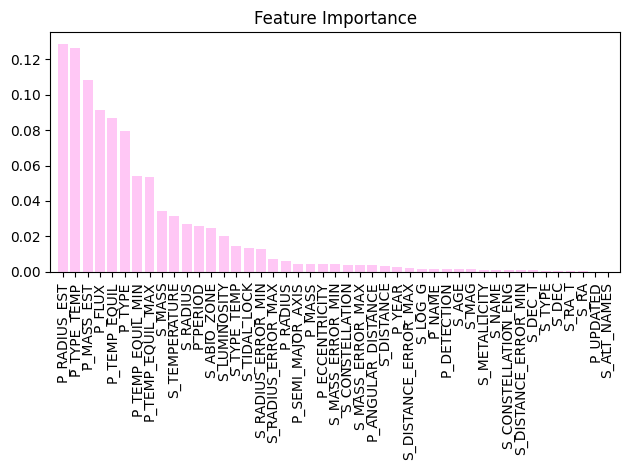

In [31]:
plt.title("Feature Importance")
plt.bar(range(X_train_smote.shape[1]),
        importance[index],
        align = 'center', 
        color= "#ffc7f5")


plt.xticks(range(X_train_smote.shape[1]),
        feat_labels[index], rotation=90)

plt.xlim([-1, X_train_smote.shape[1]])
plt.tight_layout()

plt.savefig("Feature-importance.png")
plt.show()

In [ ]:
#We removed all those features which have importance less then 1%
sfm = SelectFromModel(forest,threshold=0.01, prefit=True)
#Created a new data frame for training and testing after removing those features which had importance < 1%
X_selected_train = pd.DataFrame(sfm.transform(X_train_smote))
X_selected_test = pd.DataFrame(sfm.transform(X_test))

A = pd.DataFrame(X_selected_train)
B= pd.DataFrame(X_selected_test)

features = X_train_smote.loc[:, sfm.get_support()].columns
A.columns = features
B.columns = A.columns

print('Number of training features that meet this threshold criterion:',  X_selected_train.shape[1])
print('Number of test features that meet the threshold criteria: ', X_selected_test.shape[1])

Number of training features that meet this threshold criterion: 17
Number of test features that meet the threshold criteria:  17


c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [33]:
print("Selected features:")
for feature in features:
    print(feature)

print("\nNumber of selected features:", len(features))


Selected features:
P_PERIOD
S_MASS
S_RADIUS
S_RADIUS_ERROR_MIN
S_TEMPERATURE
P_FLUX
P_TEMP_EQUIL
P_TEMP_EQUIL_MIN
P_TEMP_EQUIL_MAX
P_TYPE
S_TYPE_TEMP
S_LUMINOSITY
S_ABIO_ZONE
S_TIDAL_LOCK
P_TYPE_TEMP
P_RADIUS_EST
P_MASS_EST

Number of selected features: 17


In A we got all the features whose feature importance was > 1% for training purpose. 

In B we got all the features whose feature importance was > 1% for testnig purpose. 

In [34]:
A.head()

,P_PERIOD,S_MASS,S_RADIUS,S_RADIUS_ERROR_MIN,S_TEMPERATURE,P_FLUX,P_TEMP_EQUIL,P_TEMP_EQUIL_MIN,P_TEMP_EQUIL_MAX,P_TYPE,S_TYPE_TEMP,S_LUMINOSITY,S_ABIO_ZONE,S_TIDAL_LOCK,P_TYPE_TEMP,P_RADIUS_EST,P_MASS_EST
0,11.979010,1.003838,0.830000,-0.070000,5299.000000,51.722206,683.225660,683.225660,683.225660,2.0,4.0,0.486654,1.768991e+35,0.440103,1.0,2.667980,7.597271
1,10.290994,0.960000,1.350000,-0.200000,5800.000000,271.582210,962.887380,785.853200,1501.609600,0.0,3.0,1.847856,2.078366e+00,0.488088,1.0,13.788300,92.170121
2,2309.336719,0.560000,0.991178,-0.242565,5490.154056,158.886886,773.292656,773.626964,772.625744,0.0,4.0,-251.849144,1.768991e+35,0.380260,1.0,12.937940,1303.094800
3,5.313500,0.700000,1.687998,-0.206697,5256.000000,200.576000,956.966820,913.004060,1009.364000,5.0,4.0,0.558480,7.346989e-01,0.409623,1.0,1.212493,1.938751
4,10.198545,1.003838,0.620000,-0.030000,4503.000000,21.582899,549.126440,549.126440,549.126440,4.0,4.0,0.141605,1.768991e+35,0.440103,1.0,1.591820,3.161273


In [35]:
B.head()

,P_PERIOD,S_MASS,S_RADIUS,S_RADIUS_ERROR_MIN,S_TEMPERATURE,P_FLUX,P_TEMP_EQUIL,P_TEMP_EQUIL_MIN,P_TEMP_EQUIL_MAX,P_TYPE,S_TYPE_TEMP,S_LUMINOSITY,S_ABIO_ZONE,S_TIDAL_LOCK,P_TYPE_TEMP,P_RADIUS_EST,P_MASS_EST
0,4.400028,0.85,0.77,-0.01,4877.0,121.665750,846.12981,846.12981,846.12981,2.0,4.0,0.300525,0.408731,0.437009,1.0,2.948230,9.001313
1,30.598700,0.42,0.40,-0.03,3466.0,1.008018,255.10464,247.83535,263.17963,2.0,5.0,0.020688,0.028616,0.345489,2.0,5.193393,23.538342
2,3.408830,1.02,1.09,-0.03,6150.0,762.467600,1338.75240,1338.75240,1338.75240,0.0,2.0,1.522797,3.869364,0.470890,1.0,13.597730,288.270000
3,70.697906,0.97,0.90,-0.03,5875.0,7.883688,426.90110,426.90110,426.90110,4.0,3.0,0.864580,2.372362,0.378030,1.0,1.759970,3.748910
4,6.079729,0.88,0.93,-0.09,5382.0,166.664390,915.38884,915.38884,915.38884,4.0,3.0,0.650174,0.984574,0.516883,1.0,1.827230,3.995385


# **TRAINING**

without hyperparameter tuning

In [45]:
models = {
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=1000),
    "Decision Tree": tree.DecisionTreeClassifier(max_depth = 5),
    "Random Forest": RandomForestClassifier(n_estimators=5),
    "SGD": SGDClassifier(),
    "Naive Bayes": GaussianNB()
  }


for name, model in models.items():
    scores = cross_val_score(model, A, y_train_smote, cv=5)
    print(name + " trained")
    print("Accuracy: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimiz

Logistic Regression trained
Accuracy: 0.33 (+/- 0.00)
Decision Tree trained
Accuracy: 1.00 (+/- 0.00)
Random Forest trained
Accuracy: 1.00 (+/- 0.00)


c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGD trained
Accuracy: 0.33 (+/- 0.00)
Naive Bayes trained
Accuracy: 0.43 (+/- 0.01)


Before the hyperparameter tuning we got; 

- **Logistic Regression:** Accuracy: **0.40 ± 0.35**
- **Decision Tree:** Accuracy: **0.40 ± 0.24**
- **Random Forest:** Accuracy: **0.44 ± 0.35**
- **Support Vector Machine:** Accuracy: **0.46 ± 0.35**
- **K-Nearest Neighbors (KNN):** Accuracy: **0.47 ± 0.24**
- **Stochastic Gradient Descent (SGD):** Accuracy: **0.47 ± 0.31**
- **Naive Bayes:** Accuracy: **0.43 ± 0.38**


While training model, multiple times, by trial and error it came to notice that features like 'P_HABZONE_OPT', 'P_HABZONE_CON', 'P_TYPE_TEMP' were causing data leakage. Due to which models were getting overfitted.


It also came to notice that only features like 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'S_DISTANCE', etc were important for classification purpose

# **TRAINNIG ALL THE MODELS**

Performing hyper parameter tunning 

In [44]:
#Decision Tree Classifier
dt_grid = GridSearchCV(tree.DecisionTreeClassifier(random_state=0), 
                    {'max_depth': [5, 7, 10], 
                        'min_samples_split': [20, 30],
                        'min_samples_leaf': [8, 10]},
                    cv=5, n_jobs=-1)
dt_grid.fit(A, y_train_smote)
print(f"Decision Tree Test: {dt_grid.score(B, y_test):.3f}")

#Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=0),
                    {'max_depth': [8, 10, 12], 'min_samples_split': [20, 30]},
                    cv=5, n_jobs=-1)
rf_grid.fit(A, y_train_smote)

print(f"Random Forest Test: {rf_grid.score(B, y_test):.3f}")


Decision Tree Test: 0.997
Random Forest Test: 0.997


In [46]:
#Scaling the training set
scaler = StandardScaler()
A_raw_scaled = scaler.fit_transform(A)
B_raw_scaled = scaler.transform(B)

print("="*60)
print("TUNING REMAINING MODELS (Raw Features Only)")
print("="*60)

# Logistic Regression 
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'max_iter': [500, 1000, 2000]
}
lr_grid = RandomizedSearchCV(LogisticRegression(random_state=0), lr_params, cv=5, n_iter=12, n_jobs=-1, random_state=0)
lr_grid.fit(A_raw_scaled, y_train_smote)



#SGD
sgd_params = {
    'loss': ['log_loss', 'hinge', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [1000, 2000, 5000]
}
sgd_grid = RandomizedSearchCV(SGDClassifier(random_state=0), sgd_params, cv=5, n_iter=15, n_jobs=-1, random_state=0)
sgd_grid.fit(A_raw_scaled, y_train_smote)


# Naive Bayes 
nb_params = {
    'var_smoothing': [1e-12, 1e-9, 1e-8, 1e-7, 1e-6]
}
nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=5, n_jobs=-1)
nb_grid.fit(A, y_train_smote)


TUNING REMAINING MODELS (Raw Features Only)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'var_smoothing': [1e-12, 1e-09, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter inde

# **MODEL COMPARISON**

In [47]:

print("COMPREHENSIVE MODEL EVALUATION (Test Set)")

# Dictionary of all models

models = {
    'Decision Tree': (dt_grid.best_estimator_, B),
    'Random Forest': (rf_grid.best_estimator_, B),
    'Logistic Regression': (lr_grid.best_estimator_, B_raw_scaled),
    'SGD': (sgd_grid.best_estimator_, B_raw_scaled),
    'Naive Bayes': (nb_grid.best_estimator_, B)
}

results = []
    

for name, (model, X_eval) in models.items():

    y_pred = model.predict(X_eval)
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy ': accuracy,
        'Precision ': precision_macro,
        'Recall ': recall_macro,
        'F1 ': f1_macro,
        'F1 (Weighted)': f1_weighted
    })



    print(f"\n{name}")
    print("-" * 70)
    print(f"  Accuracy:          {accuracy:.4f}")
    print(f"  Precision: {precision_macro:.4f}")
    print(f"  Recall:    {recall_macro:.4f}")
    print(f"  F1-Score:  {f1_macro:.4f}")
    print(f"  F1-Score : {f1_weighted:.4f}")


COMPREHENSIVE MODEL EVALUATION (Test Set)

Decision Tree
----------------------------------------------------------------------
  Accuracy:          0.9970
  Precision: 0.8571
  Recall:    0.8571
  F1-Score:  0.8182
  F1-Score : 0.9970

Random Forest
----------------------------------------------------------------------
  Accuracy:          0.9970
  Precision: 0.8886
  Recall:    0.8571
  F1-Score:  0.8423
  F1-Score : 0.9968

Logistic Regression
----------------------------------------------------------------------
  Accuracy:          0.9970
  Precision: 0.8593
  Recall:    0.9990
  F1-Score:  0.9208
  F1-Score : 0.9972

SGD
----------------------------------------------------------------------
  Accuracy:          0.9970
  Precision: 0.8571
  Recall:    0.9990
  F1-Score:  0.9086
  F1-Score : 0.9974

Naive Bayes
----------------------------------------------------------------------
  Accuracy:          0.2431
  Precision: 0.3364
  Recall:    0.4129
  F1-Score:  0.1345
  F1-Score : 0

In [48]:
# Create DataFrame from results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1 (Weighted)',
    ascending=False)

print("\nFINAL RANKING")
results_df



FINAL RANKING


,Model,Accuracy,Precision,Recall,F1,F1 (Weighted)
3,SGD,0.997036,0.857143,0.999001,0.908591,0.997438
2,Logistic Regression,0.997036,0.859259,0.999001,0.920796,0.997212
0,Decision Tree,0.997036,0.857143,0.857143,0.818182,0.997036
1,Random Forest,0.997036,0.888556,0.857143,0.842258,0.996829
4,Naive Bayes,0.243083,0.336352,0.412920,0.134478,0.381418


In [49]:

# Detailed report for best model
best_model_name = results_df.iloc[0]['Model']
best_model, best_X = models[best_model_name]
y_pred_best = best_model.predict(best_X)

print(f"\n BEST MODEL: {best_model_name}")
print("-"*70)
print(classification_report(y_test, y_pred_best, target_names=['Habitable' , 'Potentially Habitable ', 'Not-Habitable']))



 BEST MODEL: SGD
----------------------------------------------------------------------
                        precision    recall  f1-score   support

             Habitable       1.00      1.00      1.00      1001
Potentially Habitable        1.00      1.00      1.00         7
         Not-Habitable       0.57      1.00      0.73         4

              accuracy                           1.00      1012
             macro avg       0.86      1.00      0.91      1012
          weighted avg       1.00      1.00      1.00      1012



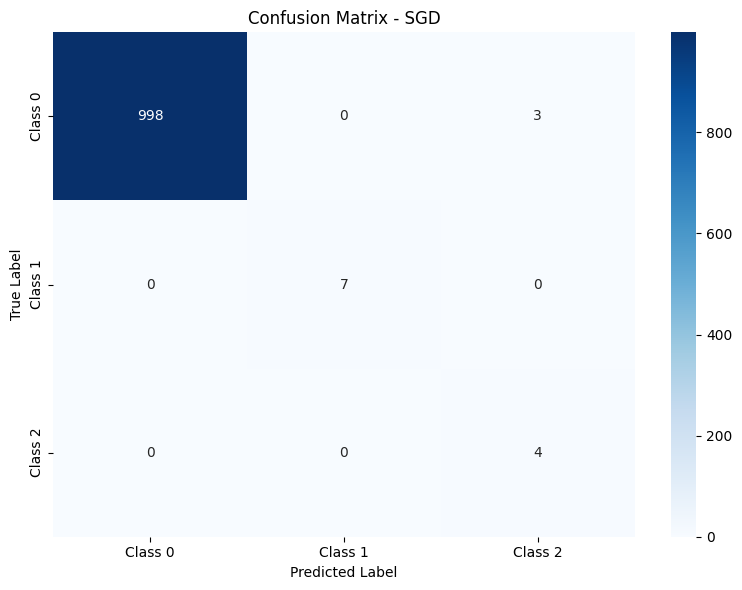

In [50]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("Confusion-Matrix-RF.png")
plt.show()

In [51]:
import pickle
pickle.dump(rf_grid.best_estimator_, open('exoplanet_classifier.pkl', 'wb'))
print("Model saved!")

Model saved!


The predictions represent the model's classification based on the selected catalog features, rather than a definitive assessment of planetary habitability

In [52]:
import pandas as pd
import numpy as np

# ============================================================
# 1. CREATE A NEW / FOREIGN PLANET
# ============================================================

new_planet = pd.DataFrame({
    'P_PERIOD': [365.25],
    'S_MASS': [1.00],
    'S_RADIUS': [1.00],
    'S_RADIUS_ERROR_MIN': [0.01],
    'S_TEMPERATURE': [5778],
    'P_FLUX': [1.00],
    'P_TEMP_EQUIL': [255],
    'P_TEMP_EQUIL_MIN': [250],
    'P_TEMP_EQUIL_MAX': [260],
    'P_TYPE': [1],
    'S_TYPE_TEMP': [1],
    'S_LUMINOSITY': [1.00],
    'S_ABIO_ZONE': [0],
    'S_TIDAL_LOCK': [0],
    'P_TYPE_TEMP': [1],
    'P_RADIUS_EST': [1.00],
    'P_MASS_EST': [1.00]
})

# Make sure columns are in EXACTLY the same order as training data
new_planet = new_planet[A.columns]

print("New Planet:")
print(new_planet)


# ============================================================
# 2. PREDICT USING EACH MODEL
# ============================================================

models = {
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
    "SGD": sgd_grid.best_estimator_,
    "Naive Bayes": nb_grid.best_estimator_
}


# ============================================================
# 3. MAKE PREDICTIONS
# ============================================================

print("\n" + "=" * 60)
print("PREDICTIONS FOR NEW PLANET")
print("=" * 60)

predictions = {}

for name, model in models.items():

    prediction = model.predict(new_planet)[0]

    predictions[name] = prediction

    if prediction == 1:
        result = "HABITABLE"
    else:
        result = "NOT HABITABLE"

    print(f"{name:<25} : {prediction} --> {result}")


# ============================================================
# 4. SHOW PREDICTIONS IN A TABLE
# ============================================================

prediction_df = pd.DataFrame({
    "Model": predictions.keys(),
    "Prediction": predictions.values()
})

prediction_df["Result"] = prediction_df["Prediction"].map({
    0: "NOT HABITABLE",
    1: "HABITABLE"
})

print("\nPrediction Summary:")
print(prediction_df.to_string(index=False))


# ============================================================
# 5. MAJORITY VOTE
# ============================================================

votes = list(predictions.values())

habitable_votes = votes.count(1)
not_habitable_votes = votes.count(0)

print("\n" + "=" * 60)
print("FINAL MAJORITY VOTE")
print("=" * 60)

print("Habitable votes    :", habitable_votes)
print("Not habitable votes:", not_habitable_votes)

if habitable_votes > not_habitable_votes:
    print("FINAL PREDICTION: HABITABLE")
elif not_habitable_votes > habitable_votes:
    print("FINAL PREDICTION: NOT HABITABLE")
else:
    print("FINAL PREDICTION: TIE")


New Planet:
   P_PERIOD  S_MASS  S_RADIUS  S_RADIUS_ERROR_MIN  S_TEMPERATURE  P_FLUX  \
0    365.25     1.0       1.0                0.01           5778     1.0   

   P_TEMP_EQUIL  P_TEMP_EQUIL_MIN  P_TEMP_EQUIL_MAX  P_TYPE  S_TYPE_TEMP  \
0           255               250               260       1            1   

   S_LUMINOSITY  S_ABIO_ZONE  S_TIDAL_LOCK  P_TYPE_TEMP  P_RADIUS_EST  \
0           1.0            0             0            1           1.0   

   P_MASS_EST  
0         1.0  

PREDICTIONS FOR NEW PLANET
Decision Tree             : 0.0 --> NOT HABITABLE
Random Forest             : 0.0 --> NOT HABITABLE
Logistic Regression       : 2.0 --> NOT HABITABLE
SGD                       : 0.0 --> NOT HABITABLE
Naive Bayes               : 1.0 --> HABITABLE

Prediction Summary:
              Model  Prediction        Result
      Decision Tree         0.0 NOT HABITABLE
      Random Forest         0.0 NOT HABITABLE
Logistic Regression         2.0           NaN
                SGD     

c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SGDClassifier was fitted without feature names
  warnings.warn(
